# A Gaussian-process discrepancy for $\alpha + {}^{44}$Ca elastic scattering

This notebook takes one real measurement, one optical potential and one piece of prior knowledge about where that potential goes wrong, and asks whether the data agree with it.

The data are differential elastic cross sections, as a ratio to the [Rutherford](https://en.wikipedia.org/wiki/Rutherford_scattering) cross section, for $^{44}$Ca($\alpha,\alpha$) at 29 MeV. They come from [EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567), measured by [Oeschler *et al.*, Phys. Rev. Lett. **28**, 694 (1972)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694), who report no uncertainties at all. A four-parameter Woods–Saxon potential describes the forward angles well and the backward angles much less well, and that disagreement is what we want to model.

We'll model it in two layers. The first is the error model of the `jitr` [$\alpha$ + Ca Bayesian calibration](https://github.com/beykyle/jitr/blob/main/examples/notebooks/alpha_ca_calibration.ipynb) (the same one `local_optical_model_calibration` uses): an inferred relative error $s$ that is uncorrelated from point to point, and an inferred relative error $b$ common to all points. The second is a mean-zero [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) discrepancy in the style of [Kennedy & O'Hagan (2001)](https://doi.org/10.1111/1467-9868.00294), which describes the *smooth*, correlated part of the misfit. We'll compare just two versions of that discrepancy:

1. one whose size is the **same at every angle**;
2. one whose size **grows as a power of the momentum transfer** $q$, with the power inferred from the data.

The second encodes a physical expectation: large momentum transfer is sensitive to shorter distances, where a simple Woods–Saxon shape is least constrained, so we trust the potential forward and are suspicious of it backward. We'll ask the data which version they prefer by [Bayesian evidence](https://en.wikipedia.org/wiki/Marginal_likelihood), then look at what each one predicts on a fine angular grid, and how well calibrated those predictions are.

It's worth looking at the [`jitr` quickstart tutorials](https://beykyle.github.io/jitr/getting-started.html) alongside this one, since we reuse their potential and priors.

Recipes: 7, 10, 13, 17, 18, 19, 40

In [1]:
import corner
import dynesty
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotstyle
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## The data

We'll take every fourth angle of the $^{44}$Ca set. That leaves 73 points between 15 and 174 degrees, which is plenty to pin down the diffraction pattern, and it keeps each fit to a few minutes. A ratio to Rutherford is dimensionless, so there are no units to convert, and the kinematics the model needs go in `meta`. There are no reported errors, so the error column is zeros, and every uncertainty below is inferred.

We'll also need the momentum transfer $q = 2k\sin(\theta/2)$, so we compute the wavenumber $k$ from the reaction's kinematics now.

In [2]:
df = pd.read_csv("data/alpha_ca_ratio_ruth.csv")
df = df[df["target"] == "Ca44"].iloc[::4]
reaction = jitr.reactions.ElasticReaction(target=(44, 20), projectile=(4, 2))
E_lab = 29.0
k = reaction.kinematics(E_lab).k
meta = {"reaction": reaction, "Elab": E_lab, "quantity": "dXS/dRuth"}
angles = np.deg2rad(df["angle_cm_deg"].to_numpy())
ratio = df["ratio_to_rutherford"].to_numpy()
data = rx.Dataset(
    angles, ratio, np.zeros(ratio.size), label="44Ca(a,a) 29 MeV", meta=meta
)
x_fine = np.deg2rad(np.linspace(10.0, 178.0, 220))

In [3]:
q_data = rx.reactions.momentum_transfer(angles, k)
print(
    f"{data.n} points between {np.rad2deg(angles.min()):.0f} and "
    f"{np.rad2deg(angles.max()):.0f} degrees, "
    f"q from {q_data.min():.2f} to {q_data.max():.2f} fm^-1"
)

73 points between 15 and 174 degrees, q from 0.56 to 4.32 fm^-1


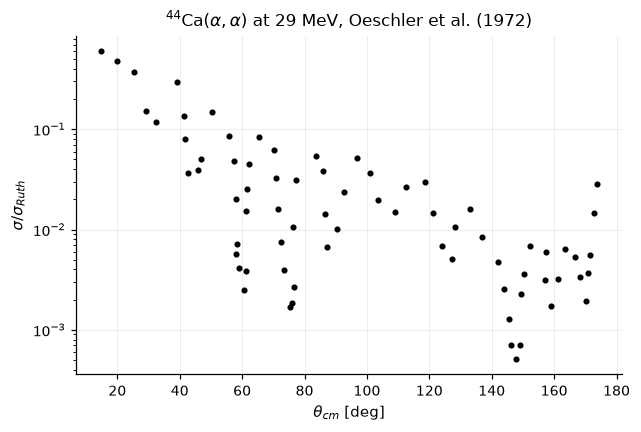

In [4]:
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k")
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title=r"$^{44}$Ca($\alpha,\alpha$) at 29 MeV, Oeschler et al. (1972)",
)
plt.show()

## The optical model

We use the same model as the `jitr` quickstart: a [Woods–Saxon](https://en.wikipedia.org/wiki/Woods%E2%80%93Saxon_potential) potential, plus the Coulomb potential of a uniformly charged sphere of radius $1.3\,A^{1/3}$ fm, with radii measured in units of $A^{1/3}$ fm. The real and imaginary volume terms share one geometry, which leaves four free parameters: $V$, $W$, $r$ and $a$. For priors we take the quickstart's typical $\alpha$-nucleus values, truncated at zero so the depths stay physical (recipe 13).

Thirty partial waves are enough to converge at this energy. The solver's default basis size agrees with the fully converged solution to within a few per cent, even at the deepest diffraction minima. That's far smaller than any of the errors we're about to infer, and it runs about two hundred times faster.

In [5]:
A13 = 44 ** (1 / 3)


def central(r, V, W, R, a):
    return -(V + 1j * W) * woods_saxon_safe(r, R * A13, a)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


params = [
    rx.Parameter("V", prior=stats.norm(150.0, 20.0), bounds=(0.0, np.inf), latex="V"),
    rx.Parameter("W", prior=stats.norm(20.0, 10.0), bounds=(0.0, np.inf), latex="W"),
    rx.Parameter("r", prior=stats.norm(1.4, 0.3), bounds=(0.8, 2.0), latex="r"),
    rx.Parameter("a", prior=stats.norm(0.5, 0.2), bounds=(0.2, 1.0), latex="a"),
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    lambda r: 0.0 * r,
    lambda ws, *x: (tuple(x), (), ()),
    params,
    coulomb=coulomb,
    lmax=30,
)
theta_0 = np.array([150.0, 20.0, 1.4, 0.5])

In [6]:
# we always draw the model on a fine grid: evaluated only at the (downsampled)
# data angles, the diffraction pattern aliases and the curve looks ragged
on_fine = omp.bind(x_fine, meta)

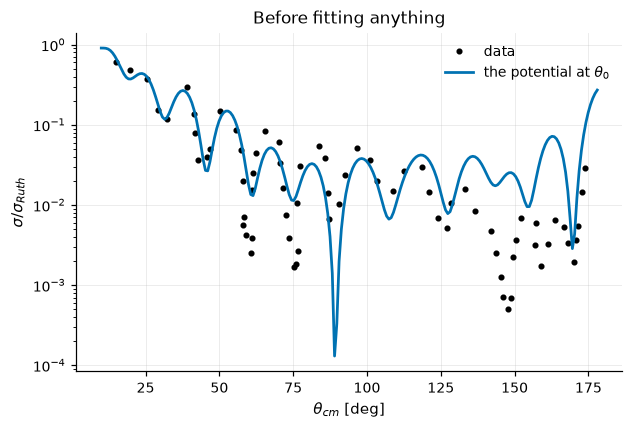

In [7]:
fig, ax = plt.subplots()
ax.plot(np.rad2deg(angles), ratio, "o", ms=3, color="k", label="data")
ax.plot(
    np.rad2deg(x_fine),
    on_fine(*theta_0),
    color=plotstyle.COLOURS[0],
    label=r"the potential at $\theta_0$",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Ruth}$",
    yscale="log",
    title="Before fitting anything",
)
ax.legend()
plt.show()

## The error model

The data span three decades, and the disagreement between a local potential and real data is naturally *relative*: a fraction of the cross section, whatever its size. Relative errors become additive in log space, so that's where we'll compare (recipe 10). `space=tf.log` transforms the data once and every prediction along with it.

### The inferred errors, $s$ and $b$

Following `jitr`, we think of each measured point as the prediction multiplied by two independent [log-normal](https://en.wikipedia.org/wiki/Log-normal_distribution) factors with mean one, $y_i = y_{m,i}\,A_i\,B$. $A_i$ is a relative error uncorrelated from point to point, and $B$ is a relative error common to all points, like an unknown normalisation. Choosing $\mathrm{Var}[B] = b^2$ and $\mathrm{Var}[A_i] = s^2/(1+b^2)$ gives, in log space,

$$\Sigma^{\log}_{ij} = \log\!\left(1 + \frac{s^2}{1+b^2}\right)\delta_{ij} + \log\!\left(1 + b^2\right),$$

which we write as two one-line `rx.Term`s (recipe 19); `local_optical_model_calibration` derives it in more detail. Both $s$ and $b$ get log-uniform priors between 5 % and 200 %, as in `jitr`.

We need $s$ for more than bookkeeping. These data were digitised from a figure with deep diffraction minima, and their log residuals scatter from one angle to the next by tens of per cent. Only an uncorrelated term can absorb that. Without it, a smooth discrepancy would be forced to become rough enough to chase every point, and it would stop describing anything about the potential.

### The discrepancy

On top of $s$ and $b$ we add a Matérn(5/2) [kernel](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function) (recipe 7), evaluated in the scaled angle $u = \theta/\pi$. It's tempting to evaluate it in $q$ itself, but $q \propto \sin(\theta/2)$ flattens out at backward angles: there, neighbouring measured angles are almost on top of each other in $q$, and a kernel would insist they agree exactly. In $u$ the measured angles are evenly spread.

The correlation length $\ell$ gets a log-uniform prior between the two natural extremes of this dataset: the spacing between neighbouring measured angles, and the full angular range they cover. That's a range of about $N$, the number of points.

The two versions differ only in the amplitude $a$ that scales the kernel, and that's where $q$ comes in:

| label | discrepancy amplitude |
|---|---|
| `constant` | $a = A$ at every angle |
| `power of q` | $a = A\,(q/2k)^{p} = A \sin^{p}(\theta/2)$, with $p$ inferred |

In the second, $A$ is the size of the discrepancy at 180 degrees and $p$ says how quickly it grows towards there; $p$ near zero would mean the data see no growth at all. $A$ is log-uniform between 5 % and 200 %, and $p$ is uniform between 0 and 4 (recipe 13).

In [8]:
comp = rx.Comparison(data, omp, space=tf.log)


def log_uniform(lo, hi):
    return stats.uniform(np.log(lo), np.log(hi) - np.log(lo))


# the jitr error model: point-to-point and common relative errors, in log space
log_s = rx.Parameter("log_s", prior=log_uniform(0.05, 2.0), latex=r"\log s")
log_b = rx.Parameter("log_b", prior=log_uniform(0.05, 2.0), latex=r"\log b")


def point_to_point_sd(c, log_s, log_b):
    s2, b2 = np.exp(2 * log_s), np.exp(2 * log_b)
    return np.full(len(c), np.sqrt(np.log1p(s2 / (1 + b2))))


def common_sd(c, log_b):
    return np.full(len(c), np.sqrt(np.log1p(np.exp(2 * log_b))))


error_terms = [
    rx.Term(point_to_point_sd, (log_s, log_b), kind="diag"),
    rx.Term(common_sd, (log_b,), kind="mode"),
]

In [9]:
def by_angle(x):
    return np.asarray(x, dtype=float) / np.pi


u_data = np.sort(by_angle(angles))
shortest, longest = np.median(np.diff(u_data)), u_data[-1] - u_data[0]
log_ell = rx.Parameter(
    "log_ell", prior=log_uniform(shortest, longest), latex=r"\log\ell"
)
log_A = rx.Parameter("log_A", prior=log_uniform(0.05, 2.0), latex=r"\log A")
log_A_q = rx.Parameter("log_A_q", prior=log_uniform(0.05, 2.0), latex=r"\log A")
power = rx.Parameter("p", prior=stats.uniform(0.0, 4.0), latex="p")


def power_of_q(c, log_amplitude, p):
    # c.x is u = theta / pi, so q / 2k = sin(theta / 2) = sin(pi u / 2)
    return np.exp(log_amplitude) * np.sin(0.5 * np.pi * np.asarray(c.x)) ** p


gp_constant = T.kernel(
    Matern(0.1, nu=2.5),
    coords=by_angle,
    amplitude=T.constant_amplitude,
    amplitude_params=(log_A,),
    params=[log_ell],
)
gp_power = T.kernel(
    Matern(0.1, nu=2.5),
    coords=by_angle,
    amplitude=power_of_q,
    amplitude_params=(log_A_q, power),
    params=[log_ell],
)

In [10]:
print(
    f"length-scale prior on u: {shortest:.4f} (one spacing) to {longest:.3f} "
    f"(the full range), a ratio of {longest / shortest:.0f} for {data.n} points"
)

length-scale prior on u: 0.0099 (one spacing) to 0.883 (the full range), a ratio of 89 for 73 points


In [11]:
gps = {"constant": gp_constant, "power of q": gp_power}
problems = {
    name: rx.Problem(
        [rx.Constraint([comp], terms=[*error_terms, gp], statistical=False)]
    )
    for name, gp in gps.items()
}
colours = {"constant": plotstyle.COLOURS[1], "power of q": plotstyle.COLOURS[0]}

In [12]:
for name, p in problems.items():
    print(f"{name:10s} columns: {p.names}")

constant   columns: ['V', 'W', 'r', 'a', 'log_s', 'log_b', 'log_ell', 'log_A']
power of q columns: ['V', 'W', 'r', 'a', 'log_s', 'log_b', 'log_ell', 'log_A_q', 'p']


## Running the calibration

Optical-model posteriors are strongly correlated and often multimodal, so we'll use [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) ([Skilling 2006](https://doi.org/10.1214/06-BA127)) through [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)). It copes well with that kind of posterior, and it computes the evidence we're about to compare as a by-product.

In [13]:
def fit_nested(problem, seed, nlive=80, dlogz=1.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    return sampler.results

In [14]:
results, samples = {}, {}
for i, (name, p) in enumerate(problems.items()):
    results[name] = fit_nested(p, seed=i)
    samples[name] = results[name].samples_equal(rstate=np.random.default_rng(i))

In [15]:
for name, res in results.items():
    print(
        f"{name:10s} log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}   "
        f"{int(np.sum(res.ncall)):6d} calls"
    )

constant   log Z =   -90.25 +/- 0.88    29792 calls
power of q log Z =   -84.86 +/- 0.98    35396 calls


## Evidence, and what a Bayes factor is

The [marginal likelihood](https://en.wikipedia.org/wiki/Marginal_likelihood), or evidence, is the probability a model assigned to the data before we asked which parameters fit best. We get it by averaging the likelihood over the prior:

$$Z = \int p(\mathbf{y} \mid \theta)\, p(\theta)\, \mathrm{d}\theta .$$

Because it's an average, it rewards models that put their probability where the data actually landed, and it penalises models that spread probability thinly over parameter space they turned out not to need. It's an automatic [Occam's razor](https://en.wikipedia.org/wiki/Occam%27s_razor): the power-of-$q$ amplitude has one more parameter than the constant one, and it only wins if that parameter earns its keep. The ratio of two evidences is the [Bayes factor](https://en.wikipedia.org/wiki/Bayes_factor), and it tells us how much the data should shift our relative belief in one model over the other.

Two practical notes. A Bayes factor depends on the priors, not just on how good the best fit is, so the prior ranges we stated above are part of the claim. And since we fitted in log space, we add `problem.log_jacobian()` so that $\log Z$ is a density for the measured ratios themselves (recipe 18). Both models share the same Jacobian, so it cancels in their Bayes factor. `compare_logz` calls the result a tie unless the difference is more than twice the combined sampler error.

In [16]:
logz = {
    name: rx.diagnostics.logz_summary(
        results[name].logz[-1] + problems[name].log_jacobian(),
        results[name].logzerr[-1],
    )
    for name in problems
}
verdict = rx.diagnostics.compare_logz(logz["power of q"], logz["constant"])

In [17]:
for name, (mean, err, _) in logz.items():
    print(f"{name:10s} log Z = {mean:8.2f} +/- {err:.2f}  (density of the ratios)")
words = {"a": "power of q favoured", "b": "constant favoured", "tie": "a tie"}
print(
    f"\npower of q vs constant: dlogZ = {verdict['dlogZ']:.2f} +/- {verdict['err']:.2f}"
    f"  ->  {words[verdict['verdict']]}"
)

constant   log Z =   224.23 +/- 0.88  (density of the ratios)
power of q log Z =   229.62 +/- 0.98  (density of the ratios)

power of q vs constant: dlogZ = 5.39 +/- 1.32  ->  power of q favoured


The data prefer the growing amplitude: $\log Z$ is $229.6$ against $224.2$, a difference of $5.4 \pm 1.3$, comfortably past the two-sigma bar `compare_logz` insists on. A log Bayes factor of about 5 means the data raise the odds of the power-of-$q$ model over the constant one by a factor of roughly $e^{5.4} \approx 200$, even after it pays for its extra parameter.

### The potential under each discrepancy

The discrepancy model changes what the data can say about the potential, so let's overlay the two posteriors for $V$, $W$, $r$ and $a$.

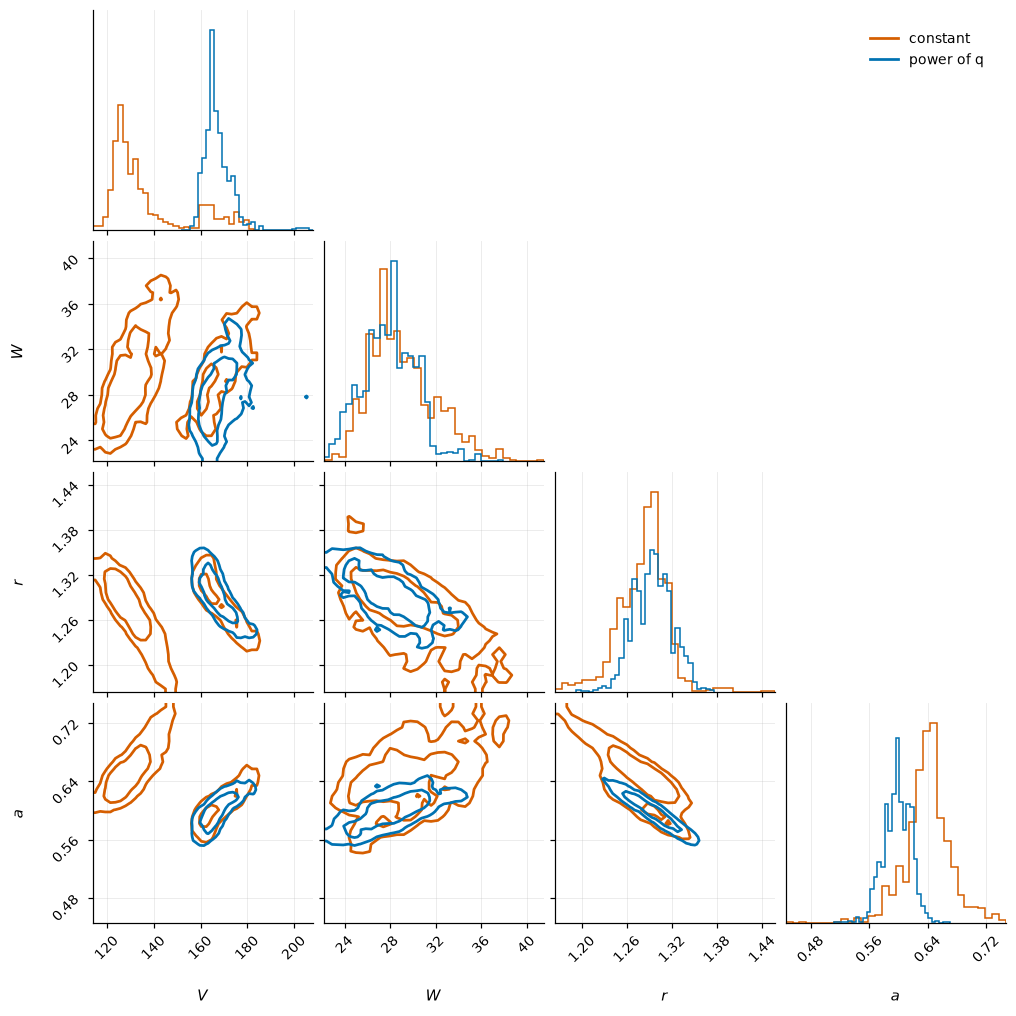

In [18]:
labels = [f"${q.latex}$" for q in params]
fig = None
for name, p in problems.items():
    fig = corner.corner(
        samples[name][:, p.columns(params)],
        fig=fig,
        labels=labels,
        **plotstyle.corner_kwargs(
            color=colours[name],
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68, 0.95),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in colours.items()],
    loc="upper right",
    bbox_to_anchor=(0.95, 0.95),
    fontsize=9,
)
plt.show()

The two posteriors for the potential don't even agree on which family of potentials to use. With a constant amplitude, the posterior for $V$ splits between a shallow family near 125 MeV and a deeper one near 165 MeV. That's the well-known discrete ambiguity of $\alpha$-nucleus potentials: depths with different numbers of interior nodes in the scattering wavefunction give nearly the same cross section. With the power-of-$q$ amplitude, nearly all the weight lands on the deeper family, and $r$ and $a$ tighten with it. A discrepancy that is allowed to be small at forward angles makes the forward data count for more, and those are what distinguish the two families.

### The inferred errors and the discrepancy's hyperparameters

Next, the error model itself: how large $s$, $b$ and the discrepancy came out, and over what correlation length.

In [19]:
hyper = {}
for name, p in problems.items():
    s = samples[name]
    amp = log_A if name == "constant" else log_A_q
    hyper[name] = {
        label: np.percentile(np.exp(s[:, p.columns(par)].ravel()), [16, 50, 84])
        for label, par in (("s", log_s), ("b", log_b), ("ell", log_ell), ("A", amp))
    }

In [20]:
for name, rows in hyper.items():
    print(name)
    for label, (lo, med, hi) in rows.items():
        print(f"    {label:3s} = {med:.3f}  (68 % interval {lo:.3f} to {hi:.3f})")

constant
    s   = 0.610  (68 % interval 0.524 to 0.764)
    b   = 0.421  (68 % interval 0.166 to 0.941)
    ell = 0.019  (68 % interval 0.015 to 0.024)
    A   = 0.611  (68 % interval 0.528 to 0.708)
power of q
    s   = 0.574  (68 % interval 0.500 to 0.743)
    b   = 0.342  (68 % interval 0.149 to 0.981)
    ell = 0.024  (68 % interval 0.017 to 0.033)
    A   = 1.139  (68 % interval 0.865 to 1.488)


Both models agree that the data scatter a lot from one angle to the next: $s$ comes out around 60 %, which is the digitisation scatter we expected. The common error $b$ is poorly constrained in both, between roughly 15 % and 95 %; a single measurement can't tell a common shift of all its points apart from the potential moving.

The correlation length comes out short in both, $\ell \approx 0.02$ in $u$, only about two point spacings, so the discrepancy describes departures that change on the scale of the diffraction pattern. The amplitudes are where the models differ: the constant one needs about 61 % everywhere, while the growing one reaches about 114 % at 180 degrees.

### How fast does the discrepancy grow?

The power $p$ is the one parameter that says whether the growth with $q$ is real. Its prior is flat between 0 and 4, so any shape in the posterior comes from the data.

In [21]:
p_q = problems["power of q"]
power_draws = samples["power of q"][:, p_q.columns(power)].ravel()
power_lo, power_med, power_hi = np.percentile(power_draws, [16, 50, 84])

In [22]:
print(f"p = {power_med:.2f}  (68 % interval {power_lo:.2f} to {power_hi:.2f})")

p = 3.22  (68 % interval 2.39 to 3.84)


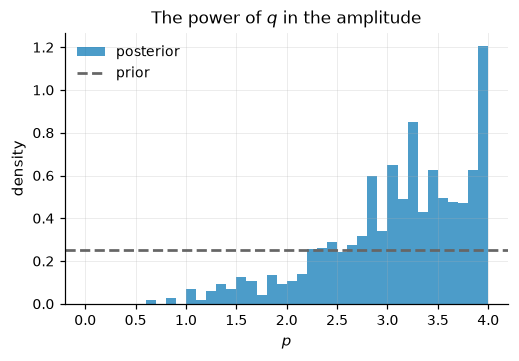

In [23]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.hist(
    power_draws,
    bins=40,
    range=(0, 4),
    density=True,
    color=colours["power of q"],
    alpha=0.7,
    label="posterior",
)
ax.axhline(0.25, color="0.4", ls="--", label="prior")
ax.set(xlabel="$p$", ylabel="density", title="The power of $q$ in the amplitude")
ax.legend()
plt.show()

The data want real growth: $p = 3.2$, with a 68 % interval from 2.4 to 3.8, far from zero. With $p \approx 3$ the discrepancy at 20 degrees is $\sin^3(10°) \approx 0.5\,\%$ of its size at 180 degrees, so in effect the data say the potential is almost exact forward and increasingly wrong backward.

## What each model predicts (recipes 17 and 40)

Now we'll draw the posterior predictive on a fine angular grid with `rx.predictive.grid_draws`, which re-evaluates every covariance term at the new angles from its own definition. For each model there are two different things we might draw:

1. **The potential alone**, $y_m(\theta;\alpha)$ with the parameters drawn from the posterior. This is our uncertainty about the *cross section the potential predicts*.
2. **The full predictive**: the potential plus the discrepancy and the inferred errors $s$ and $b$, all drawn together as one correlated curve. This is our uncertainty about *what a measurement would read*, and it's the one to lay over the data.

Every term here has a value at any angle. $s$ and $b$ are the same at every angle in log space, and the kernel and its amplitude are functions of the angle. That's exactly why the full predictive can go on the fine grid at all. `physical=True` maps the log-space draws back to ratios, so the bands are in the units of the data.

In [24]:
bands = {}
for i, (name, p) in enumerate(problems.items()):
    rows = samples[name][::10]
    bands[name] = {
        "potential alone": rx.predictive.grid_draws(
            p, on_fine, x_fine, rows, model_only=True, physical=True, levels=(5, 95)
        ),
        "full predictive": rx.predictive.grid_draws(
            p, on_fine, x_fine, rows, n_rep=2, physical=True, levels=(5, 95), rng=i
        ),
    }

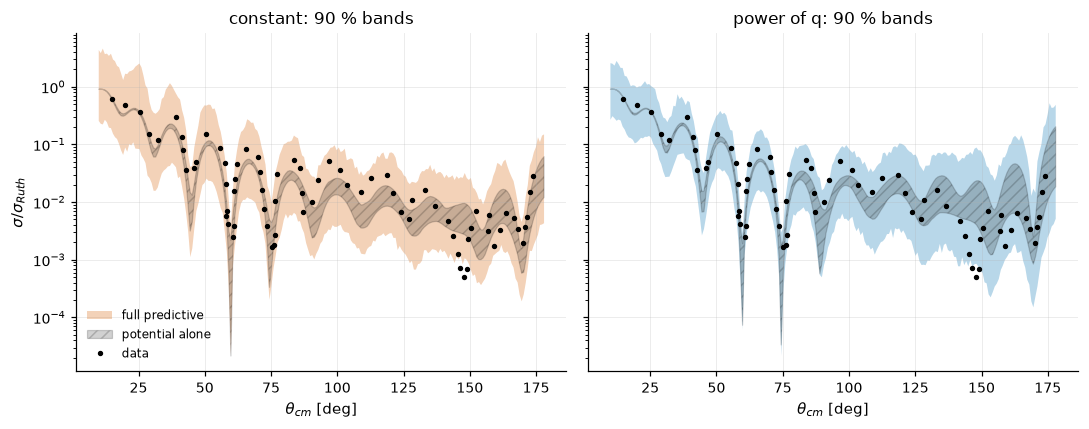

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
for ax, (name, pair) in zip(axes, bands.items()):
    lo, hi = pair["full predictive"]
    plotstyle.band(
        ax, np.rad2deg(x_fine), lo, hi, color=colours[name], label="full predictive"
    )
    lo, hi = pair["potential alone"]
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color="k",
        hatch=plotstyle.HATCHES[0],
        label="potential alone",
    )
    ax.plot(np.rad2deg(angles), ratio, "o", ms=2.5, color="k", label="data")
    ax.set(
        xlabel=r"$\theta_{cm}$ [deg]",
        yscale="log",
        title=f"{name}: 90 % bands",
    )
axes[0].set_ylabel(r"$\sigma / \sigma_{Ruth}$")
axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

At first sight the two full predictives look alike, and that's worth understanding. The uncorrelated error $s \approx 60\,\%$ is the same at every angle and dominates the width everywhere, so the discrepancy only shows through where it's comparable to $s$. That happens at backward angles, where the power-of-$q$ band opens up past 150 degrees, and in the middle of the range, where its band is a little narrower than the constant model's. In both panels the potential alone is a narrow band that misses many of the points, which is what the next check quantifies. To see the discrepancy on its own, we'll take $s$ and $b$ out at the end.

## Are the predictions calibrated?

A band is only as good as its [coverage](https://en.wikipedia.org/wiki/Coverage_probability): if a predictive distribution is calibrated, its central 68 % interval should contain about 68 % of the measured points, and likewise at every level. We check this at the measured angles with `rx.diagnostics.predictive_draws`, for the potential alone and for the full predictive.

We expect the potential alone to undercover badly. It isn't *wrong*, it answers a different question: it describes where the potential's curve is, and the data don't sit on that curve. The full predictive is the one that should follow the diagonal.

In [26]:
levels = np.linspace(0.1, 0.9, 9)
y_obs = comp.y
coverage, cov68, width68 = {}, {}, {}
for i, (name, p) in enumerate(problems.items()):
    rows = samples[name][::10]
    full = rx.diagnostics.predictive_draws(p, rows, n_rep=2, rng=i, return_draws=True)
    alone = rx.diagnostics.predictive_draws(p, rows, model_only=True, return_draws=True)
    coverage[name] = {
        "full predictive": rx.diagnostics.coverage_curve(full, y_obs, levels),
        "potential alone": rx.diagnostics.coverage_curve(alone, y_obs, levels),
    }
    cov68[name] = {
        "full predictive": rx.diagnostics.coverage_curve(full, y_obs, [0.68])[0],
        "potential alone": rx.diagnostics.coverage_curve(alone, y_obs, [0.68])[0],
    }
    width68[name] = rx.diagnostics.sharpness(full, transform=np.exp).mean()

In [27]:
for name, c68 in cov68.items():
    print(
        f"{name:10s} coverage at 0.68: "
        f"full {c68['full predictive']:.2f}, "
        f"potential alone {c68['potential alone']:.2f}; "
        f"mean 68 % width of the full predictive {width68[name]:.3f} (ratio units)"
    )

constant   coverage at 0.68: full 0.85, potential alone 0.21; mean 68 % width of the full predictive 0.082 (ratio units)
power of q coverage at 0.68: full 0.74, potential alone 0.30; mean 68 % width of the full predictive 0.060 (ratio units)


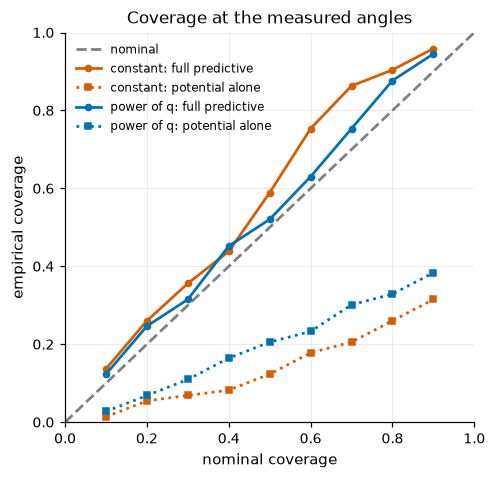

In [28]:
fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
for name, curves in coverage.items():
    ax.plot(
        levels,
        curves["full predictive"],
        "o-",
        color=colours[name],
        label=f"{name}: full predictive",
    )
    ax.plot(
        levels,
        curves["potential alone"],
        "s:",
        color=colours[name],
        label=f"{name}: potential alone",
    )
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Coverage at the measured angles",
)
ax.legend(fontsize=8)
plt.show()

At a nominal 68 %, the constant model's full predictive covers 85 % of the measured points and the power-of-$q$ model's covers 74 %, with mean 68 % widths of 0.082 and 0.060 in ratio units. So the power-of-$q$ model is both closer to nominal and sharper. The constant amplitude over-covers because it has to be as generous forward as it is backward. The potential alone covers only 21 % and 30 %, as expected for a band that leaves out every error term.

## Where the potential fails, not just how badly

Finally, the question the growing amplitude was built to answer. We can ask each model for the discrepancy alone, a mean-zero correlated draw from the kernel about the fitted potential, with `grid_draws(..., terms=[gp])`. Subtracting the posterior-median potential leaves an envelope in log space: roughly, the smooth fractional departures from the potential that the model considers plausible at each angle.

That envelope carries two things, the posterior spread of the potential and the discrepancy the kernel declares. With a constant amplitude the second is the same at every angle, so whatever shape the envelope has comes from the potential's own spread. With the power-of-$q$ amplitude it can be narrow forward and wide backward, if that's what the data support.

These envelopes are statements about the model, not predictions of a measurement: they leave out $s$ and $b$, so they don't belong next to the data. The `gp_discrepancy` notebook writes out the equations for each of these objects.

In [29]:
envelopes = {}
for name, p in problems.items():
    band = rx.predictive.grid_draws(
        p, on_fine, x_fine, samples[name][::5], terms=[gps[name]],
        levels=(16, 84), rng=3,
    )  # fmt: skip
    theta_med = np.median(samples[name], axis=0)
    mu = np.log(on_fine(*theta_med[p.columns(params)]))
    envelopes[name] = (band[0] - mu, band[1] - mu)

In [30]:
for name, (lo, hi) in envelopes.items():
    at = [np.interp(np.deg2rad(a), x_fine, hi - lo) for a in (20, 90, 170)]
    print(
        f"{name:10s} 68 % envelope width at 20, 90, 170 deg: "
        + " ".join(f"{v:.3f}" for v in at)
        + f"   back/front = {at[2] / at[0]:.1f}"
    )

constant   68 % envelope width at 20, 90, 170 deg: 1.214 1.417 1.335   back/front = 1.1
power of q 68 % envelope width at 20, 90, 170 deg: 0.040 1.433 2.364   back/front = 59.4


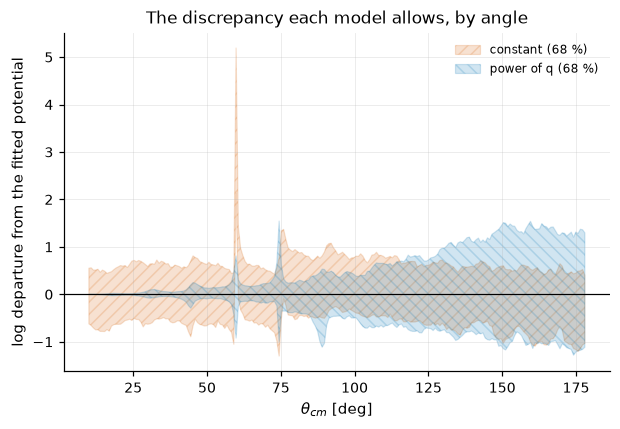

In [31]:
fig, ax = plt.subplots()
for (name, (lo, hi)), hatch in zip(envelopes.items(), plotstyle.HATCHES):
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color=colours[name],
        hatch=hatch,
        label=f"{name} (68 %)",
    )
ax.axhline(0.0, color="k", lw=0.8)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel="log departure from the fitted potential",
    title="The discrepancy each model allows, by angle",
)
ax.legend(fontsize=8)
plt.show()

This is the clearest difference. The constant amplitude's envelope is about as wide at 20 degrees (1.21) as at 170 degrees (1.34). The power-of-$q$ envelope is 0.04 wide at 20 degrees, 1.43 at 90 and 2.36 at 170, a back-to-front ratio of about 59. The narrow spikes near 60 and 75 degrees come from the diffraction minima, where the potential itself is uncertain in log space; they're the potential's spread, not the discrepancy.

## Takeaways

- A smooth discrepancy and an uncorrelated error do different jobs. Scatter from one point to the next, about 60 % here, belongs in an uncorrelated term; the discrepancy describes how the potential goes wrong coherently across angles.
- Evaluate a kernel in a coordinate where the data are spread out. Momentum transfer bunches the backward angles together, so we evaluated the kernel in angle and used $q$ only for the amplitude.
- *Where* a model fails is prior knowledge worth stating. An amplitude growing as $\sin^p(\theta/2)$ with $p \approx 3.2$ is preferred by $\Delta\log Z = 5.4 \pm 1.3$, calibrates better (74 % against 85 % at a nominal 68 %), and resolves the discrete ambiguity that the constant amplitude leaves open.
- Terms written as functions of the angle, like $s$, $b$ and the kernel, let us draw the *full* predictive on a fine grid.